# 256: BHF against 300 shuffled copies of itself

Notebook 241 searched BHF (*Botryllus* histocompatibility factor, 252 aa) against the
19_732 canonical human proteins (GENCODE v49) at 152 arms, an arm being one alphabet at
one seed length k. BHF hit something at 106 arms. Every arm gives each human protein a
score under 11 ranking metrics (E-value, bit score, mean IDF, tf-idf, enrichment, Poisson
score and p-value, shared k-mers, containment, and the two protein-level scores). Only the
E-value has a chance scale, and it exists at 61 of the 106 arms. For the other metrics a
high score says nothing on its own.

This notebook gives every metric a chance scale. BHF was searched again together with 300
shuffled copies of itself. Each copy has BHF's length, its amino-acid counts, and its count
of every adjacent residue pair (a dipeptide shuffle, Altschul and Erickson 1985). A copy
matches BHF at a median of 7.1% of positions. It has BHF's make-up and no real match in
the human proteome. Whatever a copy finds, BHF can find by chance.

Search: `256_bhf_dipeptide_shuffle_null.py`, same indexes and flags as 241 and 242, all 152
arms. A human protein's score is that of its best region. Every comparison uses the arms
where BHF itself has a score under that metric; a copy that hit nothing there counts as
finding nothing.

In [1]:
import sys
from pathlib import Path

import polars as pl

sys.path.insert(0, str(Path.cwd()))
import bhf_shuffle_null_utils as u

pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_width_chars(240)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(60)

done, total = u.progress()
print(f"search batches finished: {done} of {total}")
assert done == total, "the run is not finished; re-execute when 256_bhf_dipeptide_shuffle_null.py is done"
df = u.load()
print(f"{df.height:_} rows; {df['query_name'].n_unique()} queries (BHF + copies); "
      f"{df.select('alphabet', 'k').n_unique()} arms where any query hit anything")
print("arms per metric where BHF has a score:")
print(u.bhf_arms(df).group_by("metric").len().sort("metric"))

search batches finished: 548 of 548
293_315 rows; 301 queries (BHF + copies); 135 arms where any query hit anything
arms per metric where BHF has a score:
shape: (11, 2)
┌─────────────────────────┬─────┐
│ metric                  ┆ len │
│ ---                     ┆ --- │
│ str                     ┆ u32 │
╞═════════════════════════╪═════╡
│ E-value                 ┆ 61  │
│ Poisson p-value         ┆ 106 │
│ Poisson score           ┆ 106 │
│ bit score               ┆ 61  │
│ containment             ┆ 106 │
│ enrichment              ┆ 106 │
│ mean IDF                ┆ 106 │
│ protein Poisson p-value ┆ 106 │
│ protein enrichment      ┆ 106 │
│ shared k-mers           ┆ 106 │
│ tf-idf                  ┆ 106 │
└─────────────────────────┴─────┘


## 1. The 2024 talk's hits come back for BHF and not for its copies

The 2024 Evolgenome talk named human proteins as BHF hits at k = 24: ZNF292, RSF1, TSHZ1-3,
RNMT, SFI1/CETN2, TRAPPC10 and NDNF. The earlier chart counted the arms where one of them
is in BHF's top 10 and compared that with BHF's own hit list in random order. Here the
comparison is the same count for each shuffled copy. Ties count at their best rank, for BHF
and copies alike.

shape: (11, 9)
┌─────────────────────────┬────────┬───────────┬─────────┬───────────────────┬─────────────┬──────────────┬──────────┬───────┐
│ metric                  ┆ n_arms ┆ bhf_n_top ┆ bhf_pct ┆ copies_median_pct ┆ copies_p2_5 ┆ copies_p97_5 ┆ n_copies ┆ p     │
│ ---                     ┆ ---    ┆ ---       ┆ ---     ┆ ---               ┆ ---         ┆ ---          ┆ ---      ┆ ---   │
│ str                     ┆ i64    ┆ i64       ┆ f64     ┆ f64               ┆ f64         ┆ f64          ┆ i64      ┆ f64   │
╞═════════════════════════╪════════╪═══════════╪═════════╪═══════════════════╪═════════════╪══════════════╪══════════╪═══════╡
│ E-value                 ┆ 61     ┆ 6         ┆ 9.8     ┆ 0.0               ┆ 0.0         ┆ 3.3          ┆ 300      ┆ 0.007 │
│ bit score               ┆ 61     ┆ 6         ┆ 9.8     ┆ 0.0               ┆ 0.0         ┆ 3.3          ┆ 300      ┆ 0.007 │
│ mean IDF                ┆ 106    ┆ 7         ┆ 6.6     ┆ 1.9               ┆ 0.0         ┆ 4.7

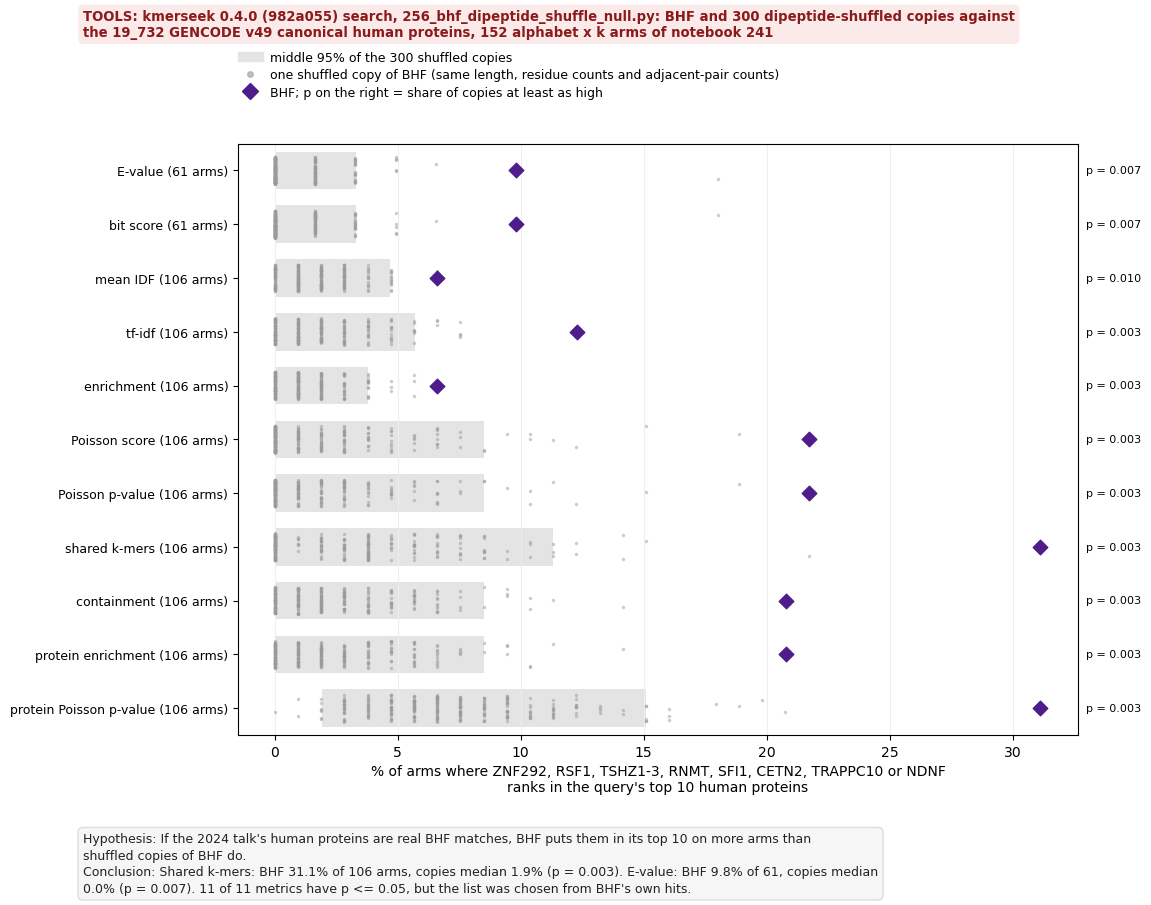

In [2]:
talk = u.talk_in_top(df)
talk_s = u.talk_summary(talk)
print(talk_s)
sk = talk_s.filter(pl.col("metric") == "shared k-mers").row(0, named=True)
ev = talk_s.filter(pl.col("metric") == "E-value").row(0, named=True)
n_low = (talk_s["p"] <= 0.05).sum()
u.fig_talk_top10(
    talk, talk_s, u.FIG / "256_talk_hits_bhf_vs_copies.png",
    hypothesis="If the 2024 talk's human proteins are real BHF matches, BHF puts them in its top 10 on more arms than shuffled copies of BHF do.",
    conclusion=(f"Shared k-mers: BHF {sk['bhf_pct']}% of {sk['n_arms']} arms, copies median {sk['copies_median_pct']}% "
                f"(p = {sk['p']}). E-value: BHF {ev['bhf_pct']}% of {ev['n_arms']}, copies median {ev['copies_median_pct']}% "
                f"(p = {ev['p']}). {n_low} of {talk_s.height} metrics have p <= 0.05, but the list was chosen from BHF's own hits."),
)

Under every metric BHF brings the 2024 proteins into its top 10 more often than any but a
few copies (p = 0.003 to 0.010). Shared k-mers: 31.1% of arms for BHF, 1.9% for the median
copy. E-value: 6 of 61 arms (9.8%) for BHF, 0% for the median copy.

This does not show the 2024 proteins are homologs. They were picked in 2024 because they
were BHF's best hits in a k-mer search. Any query's own best hits come back when the query
is searched again, and not when it is shuffled. What the result does show is narrower: the
2024 hits depend on the order of BHF's residues, not only on its make-up. A fair test would
pick each copy's own top list the same way the 2024 list was picked and ask how often it
comes back at the other arms.

## 2. BHF's best score against its copies' best scores

For each metric and arm: the share of copies whose best human hit scores at least as well
as BHF's best hit, (1 + copies at least as good) / 301. If BHF's best hit is chance, this
share is spread evenly between 0 and 1, and about 5% of arms fall at or below 0.05.

shape: (11, 6)
┌─────────────────────────┬────────┬──────────────────┬────────────────────┬────────────┬──────────┐
│ metric                  ┆ n_arms ┆ n_arms_p_le_0_05 ┆ expected_by_chance ┆ smallest_p ┆ median_p │
│ ---                     ┆ ---    ┆ ---              ┆ ---                ┆ ---        ┆ ---      │
│ str                     ┆ u32    ┆ u32              ┆ f64                ┆ f64        ┆ f64      │
╞═════════════════════════╪════════╪══════════════════╪════════════════════╪════════════╪══════════╡
│ E-value                 ┆ 61     ┆ 3                ┆ 3.1                ┆ 0.003322   ┆ 0.395349 │
│ bit score               ┆ 61     ┆ 3                ┆ 3.1                ┆ 0.003322   ┆ 0.395349 │
│ mean IDF                ┆ 106    ┆ 19               ┆ 5.3                ┆ 0.003322   ┆ 0.358804 │
│ tf-idf                  ┆ 106    ┆ 27               ┆ 5.3                ┆ 0.006645   ┆ 0.295681 │
│ enrichment              ┆ 106    ┆ 6                ┆ 5.3                ┆


best E-value over all 61 arms: BHF 0.61; median copy 0.39; copies reaching E < 1 at some arm: 291 of 300; copies with a best E at least as small as BHF's: 229 of 300


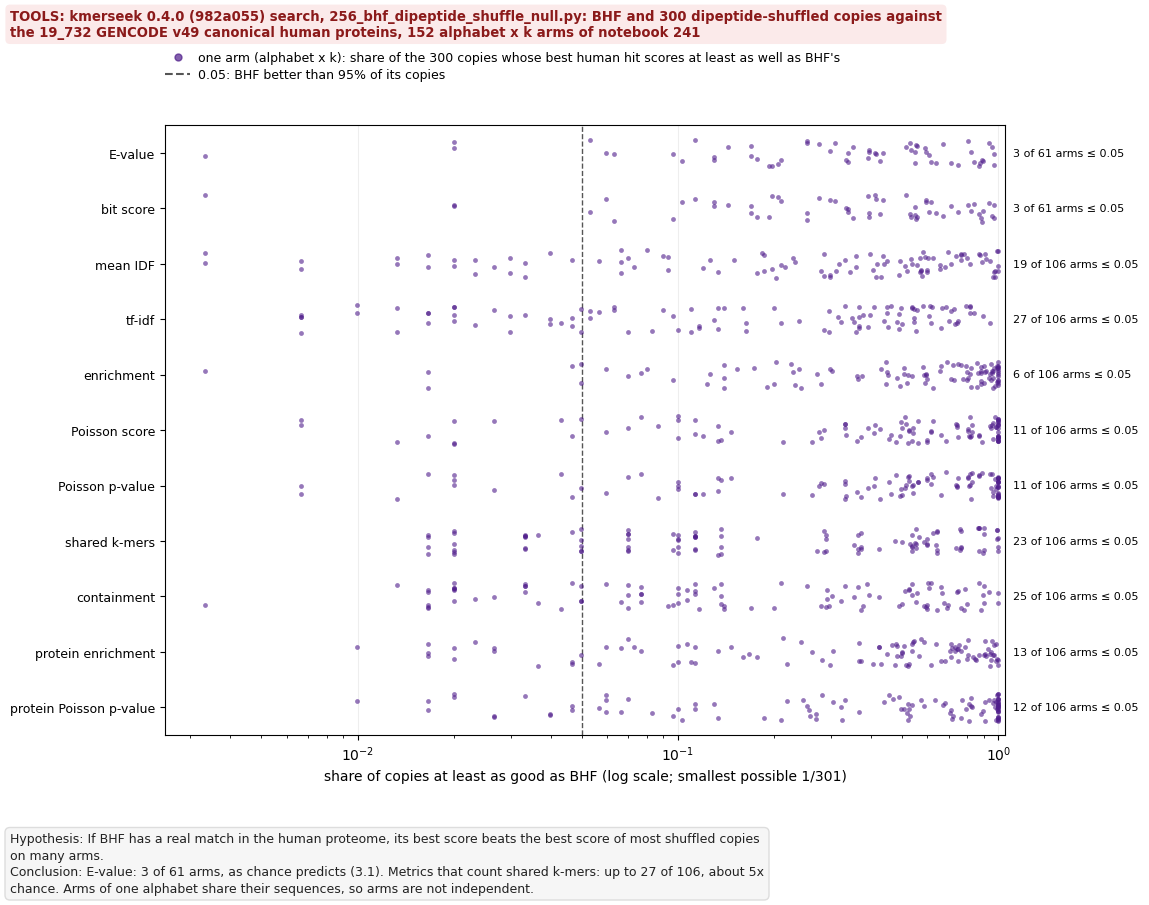

In [3]:
bp = u.best_score_p(df)
bp_s = u.best_score_summary(bp)
print(bp_s)
n_all = bp_s["n_arms"].sum(); n_hit = bp_s["n_arms_p_le_0_05"].sum()
print(f"\nall metrics: {n_hit} of {n_all} (metric, arm) cells at p <= 0.05; 5% is {0.05 * n_all:.1f}")
u.fig_best_score_p(
    bp, u.FIG / "256_best_score_bhf_vs_copies.png",
    hypothesis="If BHF has a real match in the human proteome, its best score beats the best score of most shuffled copies on many arms.",
    conclusion=(f"E-value: {bp_s.filter(pl.col('metric') == 'E-value')['n_arms_p_le_0_05'][0]} of 61 arms, as chance predicts (3.1). "
                f"Metrics that count shared k-mers: up to {bp_s['n_arms_p_le_0_05'].max()} of 106, about 5x chance. "
                "Arms of one alphabet share their sequences, so arms are not independent."),
)
e = u.full_grid(df).filter(pl.col("metric") == "E-value").group_by("query_name").agg(pl.col("top_value").min().alias("best_e"))
b = e.filter(pl.col("query_name") == "BHF")["best_e"][0]
c = e.filter(pl.col("query_name") != "BHF")["best_e"]
print(f"\nbest E-value over all 61 arms: BHF {b:.2f}; median copy {c.median():.2f}; "
      f"copies reaching E < 1 at some arm: {(c < 1).sum()} of {c.len()}; "
      f"copies with a best E at least as small as BHF's: {(c <= b).sum()} of {c.len()}")

The E-value agrees with chance. BHF beats 95% of its copies at 3 of 61 arms, and 3.1 are
expected. Over all 61 arms BHF's best E-value is 0.61; the median copy's is 0.39, 291 of 300
copies reach E < 1 at some arm, and 229 have a best E-value at least as small as BHF's.

The metrics that count shared k-mers do not agree with chance. tf-idf puts BHF above 95% of
its copies at 27 of 106 arms, containment 25, shared k-mers 23 and mean IDF 19, against 5.3
expected. Enrichment (6) is at chance. Section 3 shows where on BHF these wins come from.

## 3. Where on BHF the wins come from

For each (metric, arm) cell, the BHF region that gave BHF its best score, taken from
notebook 241's region table. The grey band counts, for every BHF residue, the cells whose
best region covers it. The purple line counts only the cells where BHF beats 95% of its
copies.

cells with a BHF region: 1076 of 1076
best region overlaps BHF 63-105: 100 of 153 winning cells; 542 of 1076 cells overall
shape: (2, 5)
┌─────────────┬─────┬──────────────────┬───────────────────┬─────────────────────┐
│ beats_95pct ┆ len ┆ median_length_aa ┆ median_share_DEKR ┆ median_entropy_bits │
│ ---         ┆ --- ┆ ---              ┆ ---               ┆ ---                 │
│ bool        ┆ u32 ┆ f64              ┆ f64               ┆ f64                 │
╞═════════════╪═════╪══════════════════╪═══════════════════╪═════════════════════╡
│ false       ┆ 923 ┆ 26.0             ┆ 0.37              ┆ 3.24                │
│ true        ┆ 153 ┆ 34.0             ┆ 0.49              ┆ 3.23                │
└─────────────┴─────┴──────────────────┴───────────────────┴─────────────────────┘

the regions behind the winning cells, BHF side and human side, most frequent first:
shape: (12, 9)
┌────────┬───────┬─────┬───────────────────────────────────────────────────────────────┬───────────

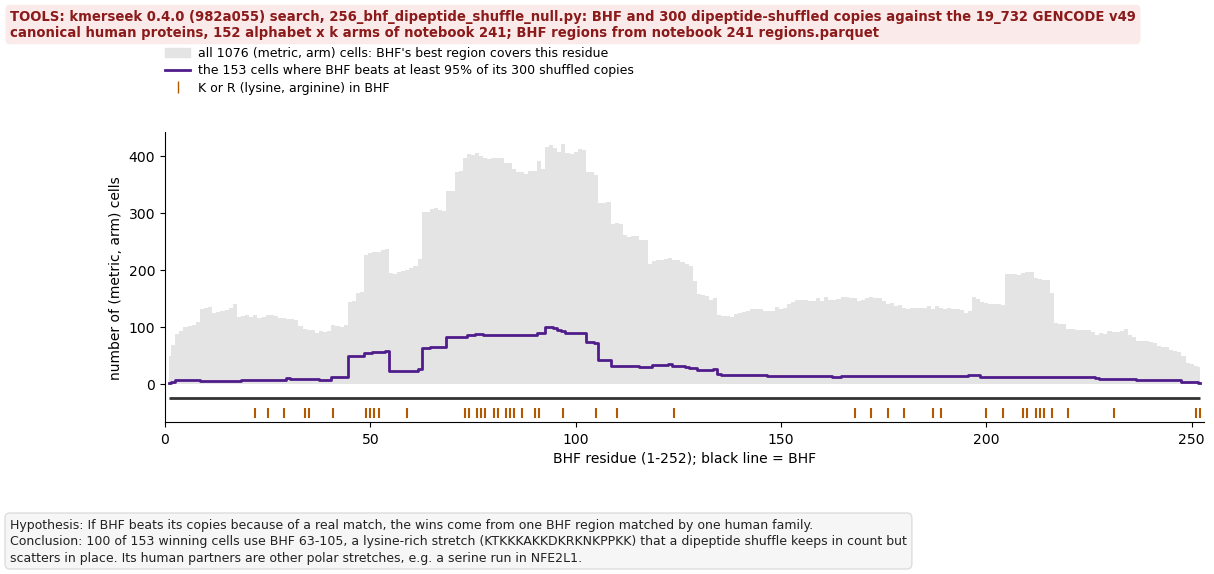

In [4]:
reg = u.bhf_best_regions(bp)
win = reg.filter(pl.col("beats_95pct"))
in_blk = lambda d: d.filter((pl.col("start") < 105) & (pl.col("end") > 62)).height
print(f"cells with a BHF region: {reg.height} of {bp.height}")
print(f"best region overlaps BHF 63-105: {in_blk(win)} of {win.height} winning cells; {in_blk(reg)} of {reg.height} cells overall")
print(reg.group_by("beats_95pct").agg(pl.len(), pl.col("length").median().alias("median_length_aa"),
                                      pl.col("charged").median().alias("median_share_DEKR"),
                                      pl.col("entropy").median().alias("median_entropy_bits")).sort("beats_95pct"))
print("\nthe regions behind the winning cells, BHF side and human side, most frequent first:")
winh = u.with_human_region(win)
print(winh.group_by("gene", "start", "end", "seq", "human_seq", "KR_bhf", "KR_human")
          .agg(pl.len().alias("n_cells"), pl.col("alphabet").unique().alias("alphabets"))
          .sort("n_cells", descending=True).head(12))
hum = u.human_sequences()
print(f"share of K or R over the human proteins ({len(hum):_} distinct gene symbols): {sum(q.count('K') + q.count('R') for q in hum.values()) / sum(map(len, hum.values())):.3f}")
cov = u.fig_region_coverage(
    reg, u.FIG / "256_where_bhf_beats_its_copies.png",
    hypothesis="If BHF beats its copies because of a real match, the wins come from one BHF region matched by one human family.",
    conclusion=(f"{in_blk(win)} of {win.height} winning cells use BHF 63-105, a lysine-rich stretch (KTKKKAKKDKRKNKPPKK) that a "
                "dipeptide shuffle keeps in count but scatters in place. Its human partners are other polar stretches, e.g. a serine run in NFE2L1."),
)

Two thirds of the winning cells (100 of 153) take their best region from BHF 63-105, which
holds the lysine-rich stretch KTKKKAKKDKRKNKPPKK. Half of all cells (542 of 1_076) use it
too, so it is where BHF's best hits sit whatever the metric; it is over-represented among
the wins, not unique to them. Winning regions are more charged: a median of 49% D, E, K or R,
against 37% for the other cells and 32.5% for BHF as a whole.

The human side of these matches is not a lysine block. NFE2L1 matches BHF 63-105 with a
serine run (SSSSSSSSSSSSSSASSS...) that has no K or R, at the two-letter hydrophobic/polar
alphabets (hp_thomas_dill2 and hp_thomas_dill_no_c2), where lysine and serine are the same
letter and both stretches read as one long polar run. DEK matches it with a stretch of
acidic and basic residues. ZNF770 is the one exact-looking match: ALHLKKRRTE (BHF 45-54)
against ALLLKKRRTE, 9 of 10 residues identical. It wins at uniprot18, where kmerseek has no
score scale and gives it no E-value; the one alphabet that does give a BHF-ZNF770 match an
E-value, dayhoff6, gives 3_436.

A dipeptide shuffle keeps BHF's residue pairs but spreads them over the protein, so a copy
loses BHF's long polar block. A human protein with a long polar or charged block of its own
then matches BHF better than it matches a copy. That is what "beats its copies" measures
here. A control that keeps each low-complexity stretch of BHF in one piece and shuffles only
the rest would test for more than that.

## 4. Proteins that come to the top for any sequence like BHF

For BHF's #1 human protein at each arm: the share of copies that have the same protein in
their own top 10 there. And the proteins most often #1 for the copies, next to how often
each is #1 for BHF.

In [5]:
sticky = u.sticky_top_hits(df)
print(u.sticky_summary(sticky))
print("\nproteins most often #1 for the copies (share of copy x arm cells), with the number of arms where each is #1 for BHF:")
print(u.top_gene_recurrence(df, 5).filter(pl.col("metric").is_in(["E-value", "mean IDF", "shared k-mers", "containment", "protein Poisson p-value"])))

shape: (11, 4)
┌─────────────────────────┬────────┬───────────────────┬─────────────────┐
│ metric                  ┆ n_arms ┆ median_pct_copies ┆ n_arms_ge_10pct │
│ ---                     ┆ ---    ┆ ---               ┆ ---             │
│ str                     ┆ u32    ┆ f64               ┆ u32             │
╞═════════════════════════╪════════╪═══════════════════╪═════════════════╡
│ E-value                 ┆ 61     ┆ 0.0               ┆ 0               │
│ bit score               ┆ 61     ┆ 0.0               ┆ 0               │
│ mean IDF                ┆ 106    ┆ 0.0               ┆ 0               │
│ tf-idf                  ┆ 106    ┆ 0.0               ┆ 1               │
│ enrichment              ┆ 106    ┆ 0.0               ┆ 0               │
│ Poisson score           ┆ 106    ┆ 0.0               ┆ 0               │
│ Poisson p-value         ┆ 106    ┆ 0.0               ┆ 0               │
│ shared k-mers           ┆ 106    ┆ 0.0               ┆ 0               │
│ containm

Under containment and protein enrichment, BHF's #1 protein is also in the top 10 of at least
10% of the copies at 33 of 106 arms; under the protein Poisson p-value at 23. TTN (35_991 aa)
is the #1 hit in 27.4% of all copy × arm cells under containment, and it is BHF's #1 at 19
arms. These metrics favour very long proteins, so for them BHF's #1 hit is what any sequence
of BHF's make-up gets. Under the region-level metrics (E-value, mean IDF, tf-idf, shared
k-mers) no protein is #1 for more than 0.9% of the copy × arm cells.

## Summary

How BHF's result changes with the ranking metric, now that every metric has a chance scale:

- **E-value** (61 arms): chance. BHF beats 95% of its copies at 3 arms, 3.1 expected. Its
  best E-value, 0.61, is matched or beaten by 229 of 300 copies.
- **tf-idf, containment, shared k-mers, mean IDF** (106 arms): BHF beats 95% of its copies at
  19 to 27 arms, 4 to 5 times chance. Two thirds of these wins come from BHF's lysine-rich
  stretch (63-105), matched to other polar stretches, such as a serine run in NFE2L1 at the
  two-letter alphabets. A dipeptide shuffle breaks up that stretch, so this is a
  low-complexity match, not evidence of homology.
- **Poisson score and p-value, protein enrichment, protein Poisson p-value**: 11 to 13 arms,
  about twice chance. **Enrichment**: 6, chance.
- **Containment, protein enrichment and the protein Poisson p-value** reward long proteins:
  TTN and MUC16 come to the top for BHF and its copies alike.
- The 2024 talk's hits return for BHF and not for its copies under every metric. They were
  chosen from BHF's own hits, so this shows they depend on the order of BHF's residues, not
  that they are homologs.

Next: a control that keeps BHF's low-complexity stretches in one piece and shuffles the rest.
If BHF still beats those copies, the match is more than a lysine block.